# 03 -- Area-Proportional Venn Diagrams

Standard Venn diagrams use fixed templates: every region has the same visual size
regardless of how many items it contains. **Area-proportional** (or
*Euler-proportional*) diagrams resize the circles so that the area of each region
matches the number of items it holds. This notebook covers:

- When proportional diagrams help (and when they don't)
- How to request one with `model='proportional'`
- The accuracy difference between 2-set (exact) and 3-set (approximate)
- Why 4+ sets are unsupported and what to use instead


In [1]:
import venn_diagram_lab as vdl

print(f'venn-diagram-lab {vdl.__version__}')

venn-diagram-lab 0.6.0


## When to use proportional diagrams

Use proportional mode when **set sizes differ widely** and you want the diagram
to convey magnitude at a glance. For example, comparing a 50-item catalog with a
5-item subset makes the size imbalance invisible on a standard template but
obvious on a proportional one.

Stick to the standard template when:
- Sets are similar in size (the gain is cosmetic)
- You have 4 or more sets (proportional is not supported)
- Exact topology matters more than visual area (e.g., every region must be visible)


In [2]:
# 2-set dataset: Catalog A (50 items) vs Catalog B (8 items, 3 shared)
ds_2 = vdl.Dataset.from_dict({
    'Catalog A': {f'a{i}' for i in range(50)},
    'Catalog B': {f'b{i}' for i in range(5)} | {f'a{i}' for i in range(3)},
})
print('Catalog A:', len(ds_2.items['Catalog A']), 'items')
print('Catalog B:', len(ds_2.items['Catalog B']), 'items')
print('Shared (A & B):', len(ds_2.items['Catalog A'] & ds_2.items['Catalog B']), 'items')

Catalog A: 50 items
Catalog B: 8 items
Shared (A & B): 3 items


## Templated vs proportional (2-set)

We render the same dataset twice: once with the standard 2-set template and once
with the proportional renderer. The counts are identical -- only the visual areas change.

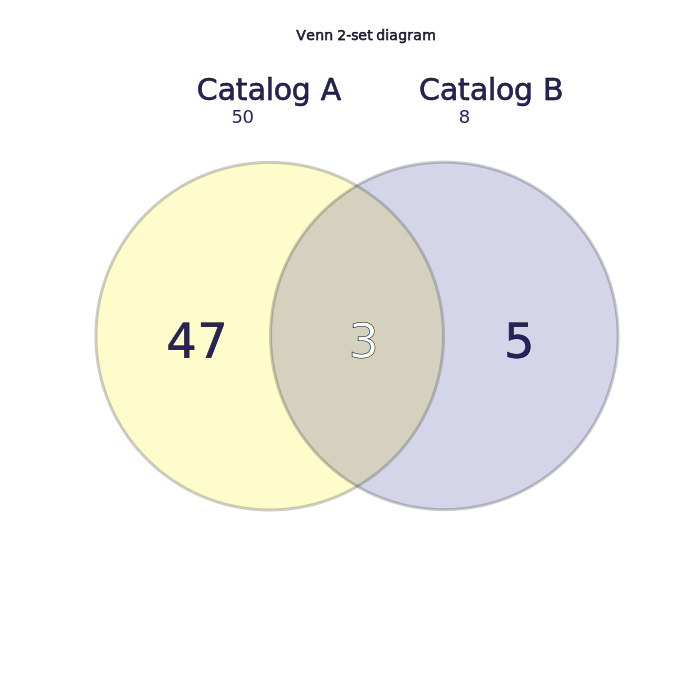

In [3]:
r_template = vdl.analyze(ds_2, model='venn-2-set')
r_template.render_venn()  # standard fixed-size circles

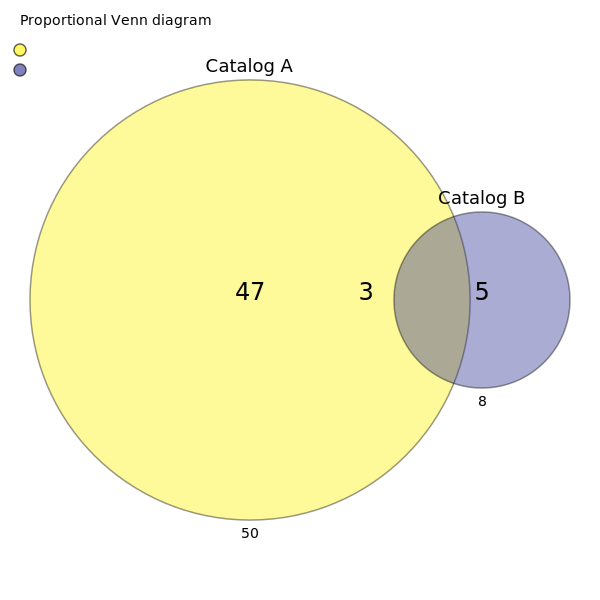

In [4]:
r_prop = vdl.analyze(ds_2, model='proportional')
r_prop.render_venn()  # circles sized to set cardinality

### Observation

In the templated diagram both circles look roughly the same size, making the
50-vs-8 ratio invisible. In the proportional diagram Catalog A's circle is
noticeably larger, immediately communicating the size imbalance.

When set sizes differ widely, proportional makes the relative difference
visually obvious without requiring the reader to read the numbers first.

In [5]:
# For 2-set diagrams the solver is analytical (binary search on lens area).
print('is_approximate:', r_prop.is_approximate)
# Expected: False

is_approximate: False


## 3-set proportional (approximate)

Three mutually overlapping circles cannot always be placed so that *every* region
area is exactly proportional -- the mathematical constraints are over-determined.
The solver does its best via a triangulation approach and marks the result as
approximate. An `'approximate'` footnote appears in the bottom-right of the SVG.

is_approximate: True


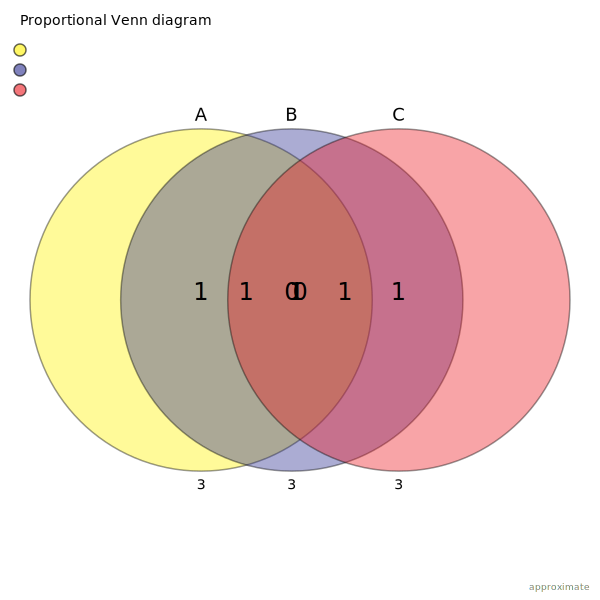

In [6]:
ds_3 = vdl.Dataset.from_dict({
    'A': {'x', 'y', 'z'},
    'B': {'y', 'z', 'w'},
    'C': {'z', 'w', 'v'},
})
r_3prop = vdl.analyze(ds_3, model='proportional')
print('is_approximate:', r_3prop.is_approximate)
r_3prop.render_venn()

### Why 3-set area-proportionality is hard

With two circles the only free parameter is the inter-center distance, and there
is always an exact solution. With three circles we have six free parameters (two
center coordinates per circle) but seven region-area constraints -- an overdetermined
system. The solver uses pairwise distance fitting to minimize total area error, but
perfect proportionality is not guaranteed. The `'approximate'` footnote in the
diagram flags this limitation so readers are not misled.

## 4+ sets are unsupported

Beyond three sets there is no known general algorithm for area-proportional circle
packing. Requesting `model='proportional'` on a 4-set dataset raises
`IncompatibleModelError` when you call `render_venn()`.

In [7]:
ds_4 = vdl.Dataset.from_dict({chr(ord('A') + i): {f'x{i}'} for i in range(4)})
r_4 = vdl.analyze(ds_4, model='proportional')
try:
    r_4.render_venn()
except vdl.IncompatibleModelError as e:
    print(f'Expected error: {e}')

Expected error: Proportional rendering supports only 2-3 sets, got 4


For 4+ sets the right alternatives are:

- **UpSet plot** (`result.render_upset()`) -- shows all intersection sizes as bars,
  scales to 9+ sets, exact counts
- **Network plot** (`result.render_network()`) -- shows pairwise relationships as
  a force-directed graph, useful for spotting clusters

Both are demonstrated in notebook **04 -- UpSet vs Venn vs Network**.

## Next steps

- [`04_upset_vs_venn_vs_network.ipynb`](04_upset_vs_venn_vs_network.ipynb) -- comparing UpSet, Venn, and Network views for large set counts
- [`05_statistics_deep_dive.ipynb`](05_statistics_deep_dive.ipynb) -- Jaccard, Dice, and hypergeometric enrichment details
- [`07_pdf_reports.ipynb`](07_pdf_reports.ipynb) -- generate a publication-ready multi-page PDF report
